In [ ]:
Name: Elsa Ingrid Daniela Erkfeldt
Civil registration number: 20030902-1228
LLM: NO LLM used

In [ ]:
import random
import numpy as np
random.seed(42)
np.random.seed(42)

from tensorflow.keras.datasets import mnist, cifar10
import numpy as np
rng = np.random.default_rng(42)  # seed for reproducibility
import tensorflow as tf
from tensorflow.keras import layers, models

import random
import torch

torch.manual_seed(42)

from matplotlib import pyplot as plt

In [2]:

#Load and prepare MNIST data
(x_raw, y_raw), (x_test_raw, y_test)= mnist.load_data()

val_size = int(x_raw.shape[0] * 0.3)
idx = np.arange(x_raw.shape[0])
rng.shuffle(idx)

val_idx = idx[:val_size]
train_idx = idx[val_size:]

(x_train_raw, y_train), (x_val_raw, y_val) = (x_raw[train_idx], y_raw[train_idx]), (x_raw[val_idx], y_raw[val_idx])
    
x_train, x_test, x_val= x_train_raw/255.0, x_test_raw/255.0, x_val_raw/255.0

x_test_extra = x_test[..., None]     
x_train_extra = x_train[..., None]  
x_val_extra = x_val[..., None]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
#CNN network to train it
model = models.Sequential([
    layers.Input(shape = (28,28,1)),
    #1
    layers.Conv2D(filters=16, kernel_size = (3,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    #2
    layers.MaxPooling2D((2,2)),

    #3
    layers.Conv2D(filters=32, kernel_size=(3,3)),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    #4
    layers.MaxPooling2D((2,2)),

    #5
    layers.Flatten(),
    layers.Dense(128, activation = "relu"),
    layers.Dropout(0.4),

    #6
    layers.Dense(10, activation = "softmax")
])

#Training of the model
model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"]) #Is the loss and metrics correct?
fitted = model.fit(x_train_extra, y_train, epochs = 5, batch_size = 64, validation_data = (x_val_extra, y_val))

test_loss, test_acc = model.evaluate(x_test_extra, y_test)
print("Test accuracy: ", test_acc)

Epoch 1/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9130 - loss: 0.2802 - val_accuracy: 0.9575 - val_loss: 0.1411
Epoch 2/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9709 - loss: 0.0965 - val_accuracy: 0.9767 - val_loss: 0.0754
Epoch 3/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9783 - loss: 0.0720 - val_accuracy: 0.9812 - val_loss: 0.0600
Epoch 4/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9800 - loss: 0.0640 - val_accuracy: 0.9867 - val_loss: 0.0455
Epoch 5/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9828 - loss: 0.0560 - val_accuracy: 0.9857 - val_loss: 0.0483
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9883 - loss: 0.0349
Test accuracy:  0.9883000254631042


Accuracy of about 98.8 % obtained

Greedy random search:
Start from correctly identified image
Add salt and paper noise until the image is misclassified
In each step, keep the new image if the prob of predicting true class decreases.
Else, go back to the old image and add noise again.


In [20]:
#pick an image that the model classifies correctly

index_list = []
for n in range(3):
    pred = 0
    actual = np.inf
    while pred!= actual:
        picked_index = random.randint(0, len(x_test_extra)-1)

        probs = model(x_test_extra[picked_index:picked_index+1]).numpy()[0]   # x_train[5:6] has shape (1,28,28,1)
        pred = np.argmax(probs)
    
        actual = y_test[picked_index]
    index_list.append([picked_index, probs, pred, actual])


true label is 9 and prediction is 8, took 14 steps


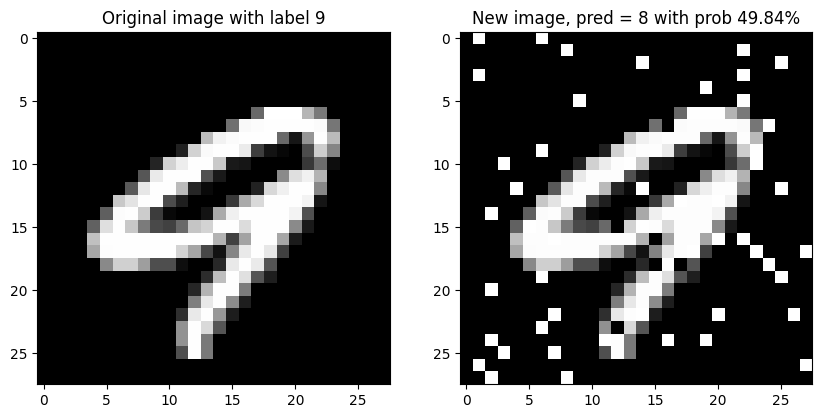

true label is 8 and prediction is 5, took 172 steps


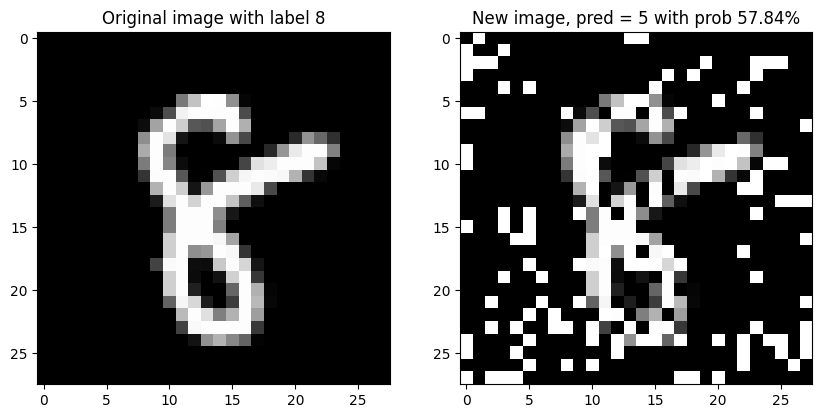

true label is 4 and prediction is 8, took 26 steps


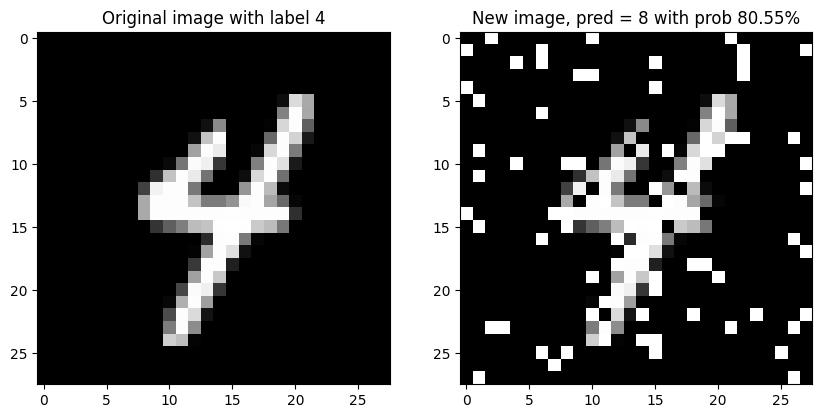

In [22]:



#Fucntion that returns the predicted class and the probability for each class
def predict(model, image):
    probabilities = model(image, training = False).numpy()[0]
    pred = int(np.argmax(probabilities))
    return pred, probabilities


def greedy_random_search(model, image, true_label, max_step = 10000):
    n  = 10

    x_old = image.copy()

    pred, probs = predict(model, image)

    old_prob = probs[true_label]
    prob_predicted = None

    step = 0

    pred_new = pred

    while pred_new == true_label and step < max_step:

        H, W = x_old.shape[1], x_old.shape[2]   # 28, 28
        x_coords = [random.randint(0, W-1) for _ in range(n)]
        y_coords = [random.randint(0, H-1) for _ in range(n)]


        salt_pepper = [random.randint(0, 1) for _ in range(n)]


        x_new = x_old.copy()

        for i in range(n):
            x_new[0, y_coords[i], x_coords[i], 0] = salt_pepper[i]
    
        pred, probs = predict(model, x_new)

        if probs[true_label] < old_prob:
            old_prob = probs[true_label]
            x_old = x_new.copy()
            pred_new = pred
            prob_predicted = probs[pred_new]
            

        step += 1
    print(f"true label is {true_label} and prediction is {pred_new}, took {step} steps")
    return x_old, pred_new, prob_predicted

for idx in range(len(index_list)):
    picked_index, probs, pred, actual = index_list[idx]
    x_original = x_test_extra[picked_index:picked_index+1].copy()
    x_old, pred_new, prob_predicted = greedy_random_search(model, x_original, actual, max_step = 10000)
    final_image = x_old
    starting_image = x_original
    final_predicted_class = pred_new
    final_probability = prob_predicted

    #Generate figures of original image and new image
    plt.figure(figsize=(10,10))
    plt.subplot(1,2,1)
    plt.imshow(x_original[0, ..., 0], cmap = "gray")
    plt.title(f"Original image with label {actual}")

    plt.subplot(1,2,2)
    plt.imshow(x_old[0, ..., 0], cmap = "gray")
    plt.title(f"New image, pred = {final_predicted_class} with prob {(final_probability*100):.2f}%")

    plt.show()


The greedy random search produced images that a human could recognise as the numbers are, but that the model predicts is something else. It is still very clearly visible to a human that it is something wrong with the images, they are visibily noisy. 
Producing the images took between 14 and 172 steps.

Boundary attack_
Start with target image T, with ground truth class label C_T and another image I that is classified (label C_I) as something else than the target class
Then tweak I towards T, making it resemble the target
If CNN still classifies that image as C_I -> Successful
Otherwise -> Step rejected, then a smaller step is tried 
Implement and run ovar a few MNIST images

In [ ]:
def boundary_attack(ci_image, target_image, model, ci_predicted, n, max_step = 5000, n_min = 1, n_max = 2000):
    #Tweak image ci towards T

    best_image = ci_image.copy()
    best_pred = ci_predicted
    best_dist = float(np.linalg.norm((best_image - target_image).ravel()))
    best_step = 0
    best_n = n

    current = ci_image.copy()

    dif_ys, dif_xs = np.where(np.abs(target_image[0,...,0]-ci_image[0,...,0]) > 0.2)
    for step in range(1, max_step+1):
        if n < n_min:
            break

        if len(dif_xs) >= n:
            idx = np.random.choice(len(dif_xs), size=n, replace=False)
            y_indx = dif_ys[idx]
            x_indx = dif_xs[idx]
        else:
            
            x_indx = np.array([random.randint(0, current.shape[1]-1) for _ in range(n)])
            y_indx = np.array([random.randint(0, current.shape[0]-1) for _ in range(n)])

        temporary = current.copy()

        temporary[0, y_indx, x_indx, 0] = target_image[0, y_indx, x_indx, 0]


        #If CNN still classifies image as belonging to class C_I
        predicted, probs = predict(model, temporary)
        dist = np.linalg.norm((temporary-target_image).ravel())
        if predicted == ci_predicted:
            #Perturbation was successful
            current = temporary

            dist = np.linalg.norm((temporary-target_image).ravel())



            if dist < best_dist: 
                best_dist = dist
                best_image = current.copy()
                best_pred = predicted
                best_step = step
                best_n = n
            
            n = min(n_max, int(n*1.1))
        
        else: 
            n = max(n_min, n//2)
    print("best dist", best_dist)
 
    return best_image, best_pred, best_dist, best_step, best_n, n




best dist 6.321513890679192


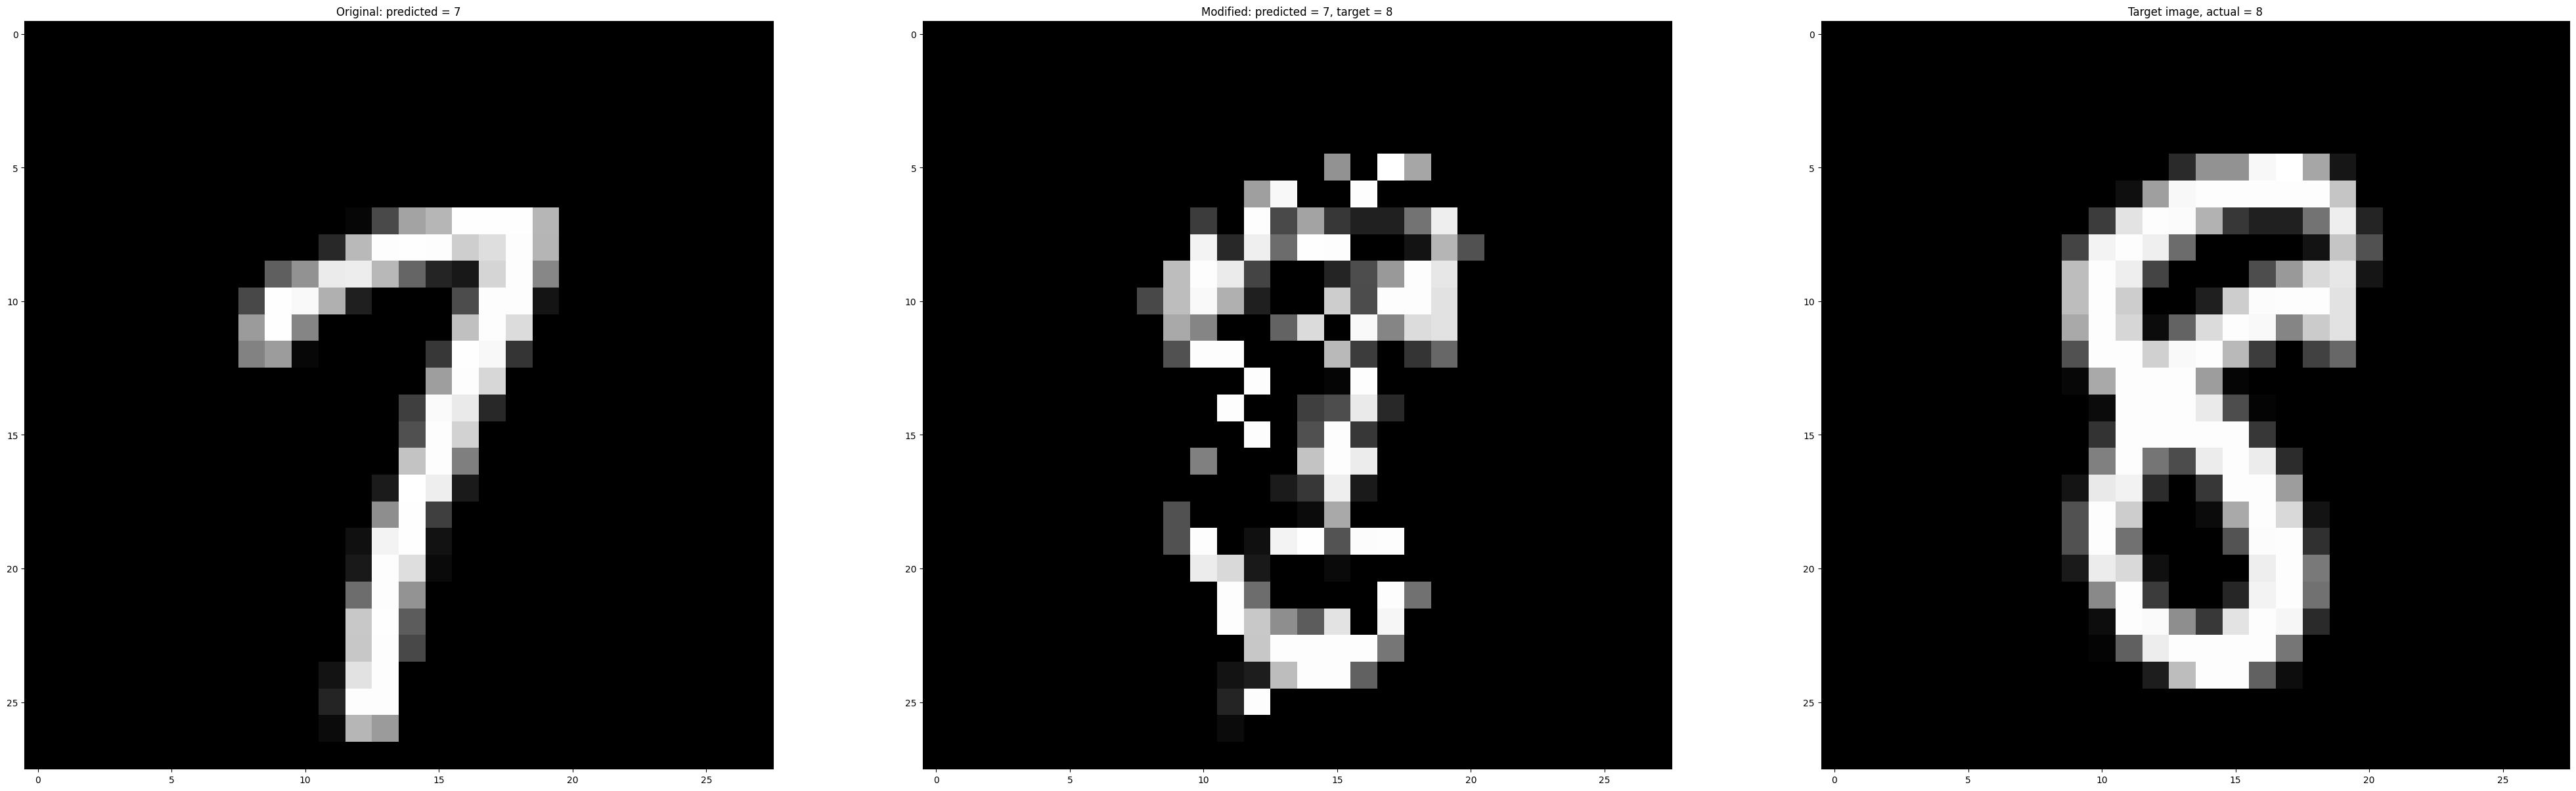

best dist 1.857395827986694


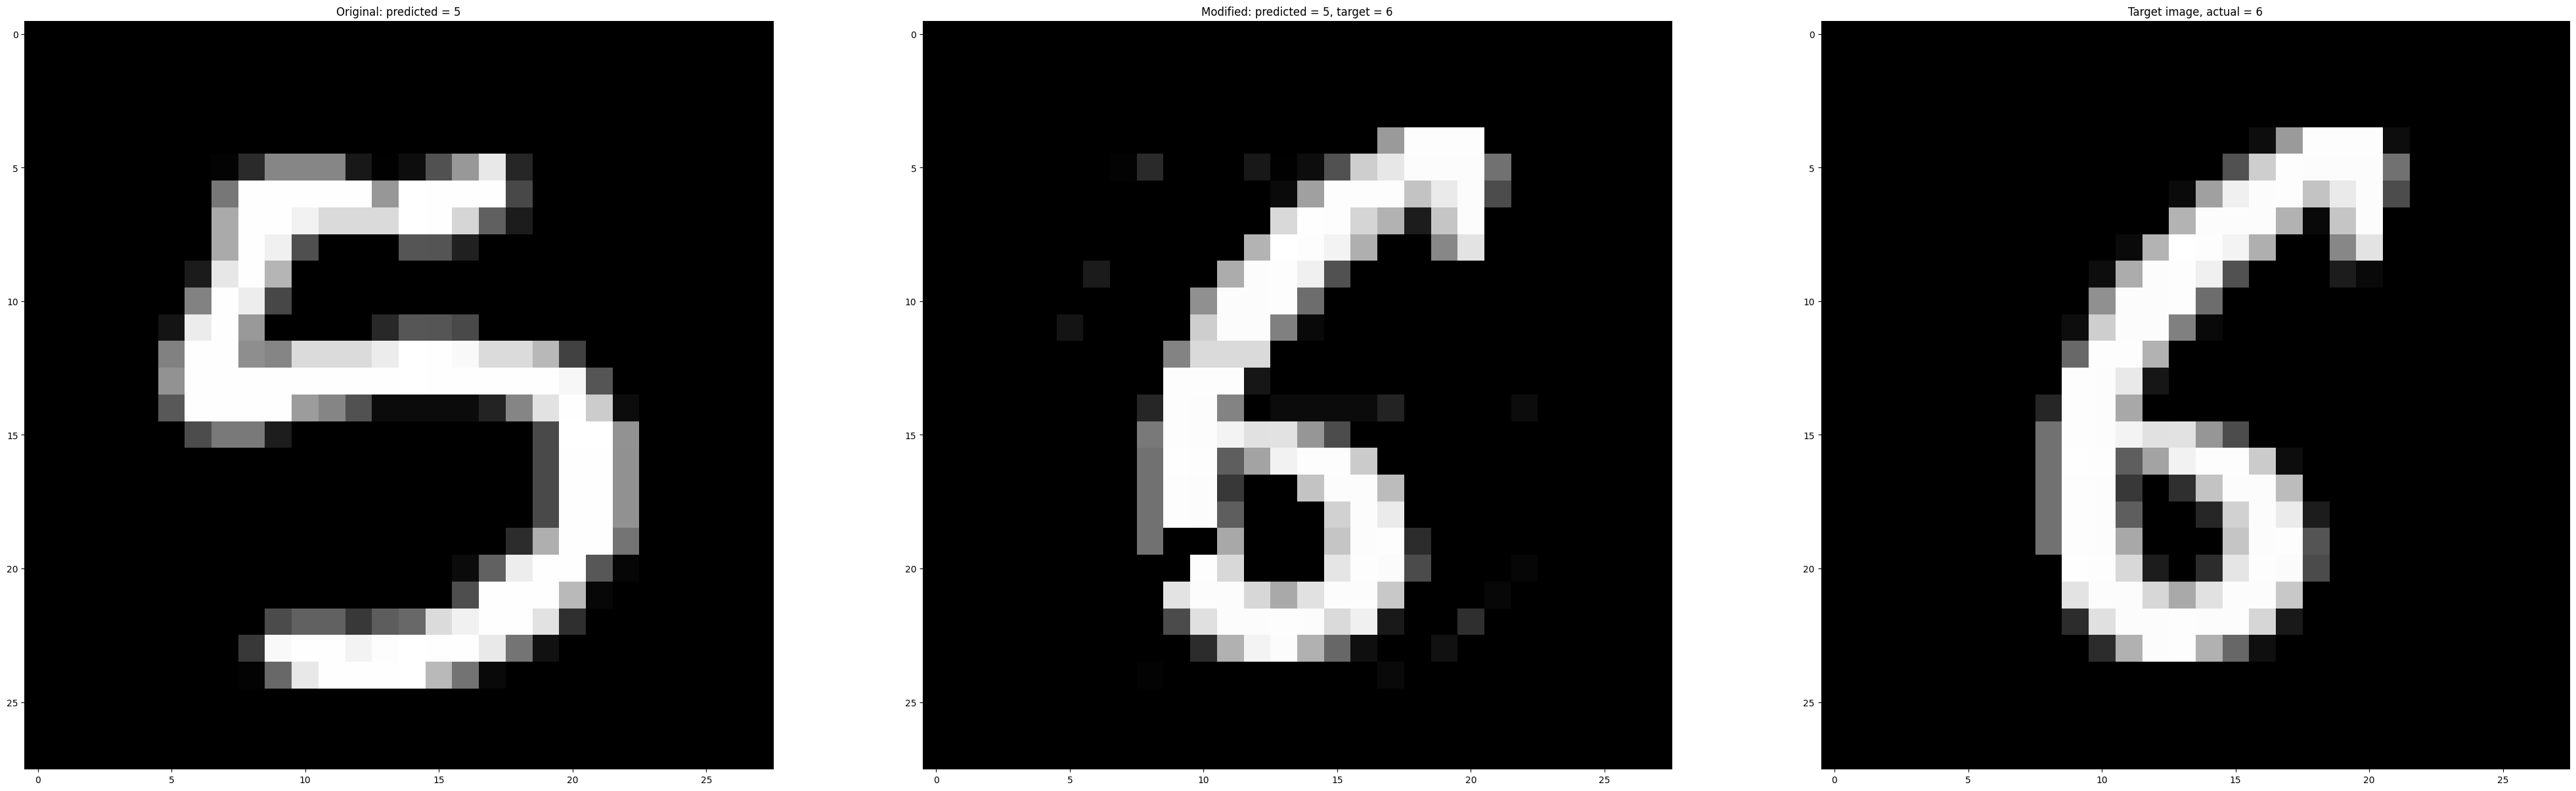

best dist 4.59969074399655


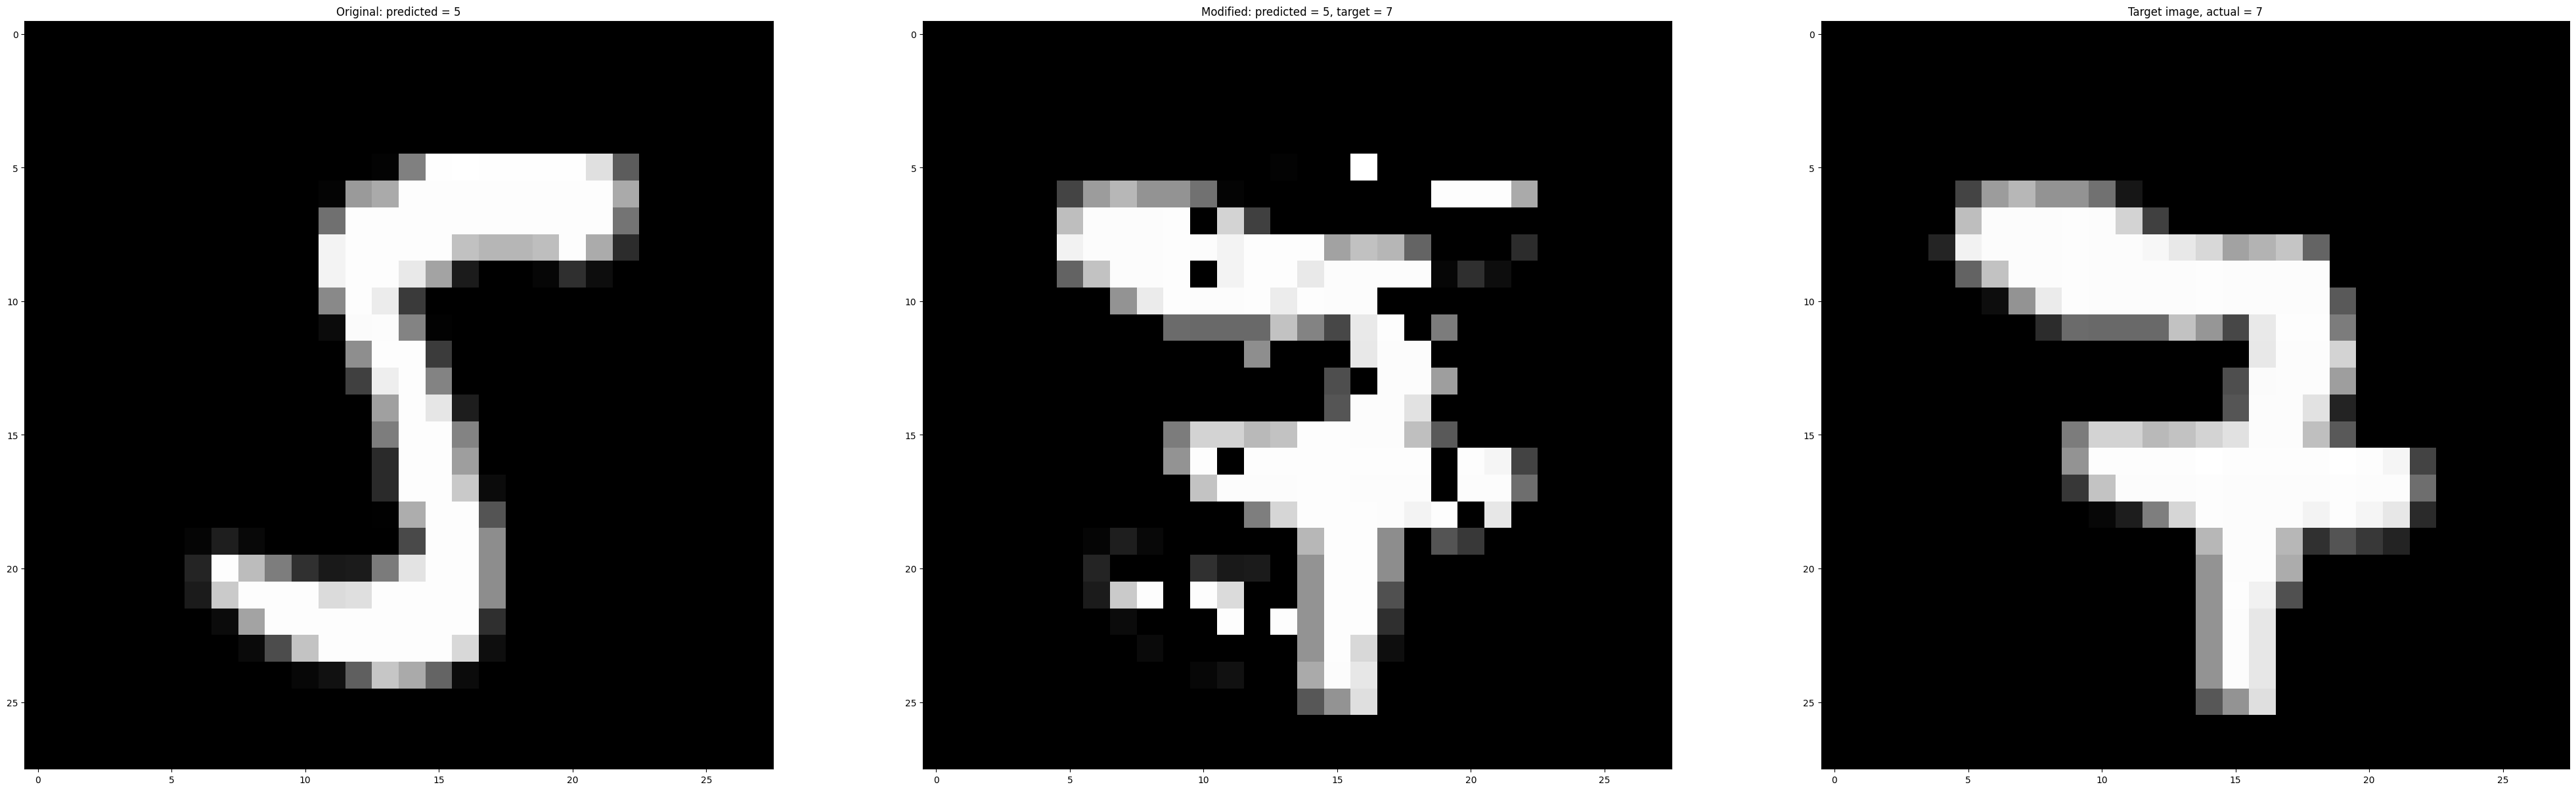

In [16]:
images_num = 3

#Find three actual images and three target iamges
for i in range(images_num):
    target_found = False
    while target_found == False:
        index = random.randint(0, len(x_test_extra)-1)
        pred, probs = predict(model, x_test_extra[index:index+1])
        if pred == y_test[index]:
            target_found = True

            target_indx = index
            target_actual = y_test[index]
            target_probabilities = probs
            target_image = x_test_extra[target_indx:target_indx+1]

    I_found = False
    while I_found == False:
        index = random.randint(0, len(x_test_extra)-1)
        pred, probs = predict(model, x_test_extra[index:index+1])
        if pred != target_actual:
            I_found = True

            ci = index
            ci_predicted = pred
            i_probabilities = probs
            ci_image = x_test_extra[index: index+1]


    number_of_pixels_edited = 50


    #DO a boundary attack for the picked image
    best_image, best_pred, best_dist, best_step, best_n, n = boundary_attack(ci_image, target_image, model, ci_predicted, number_of_pixels_edited)

    #Plot original, modified and target image
    plt.figure(figsize = (50, 50))
    plt.subplot(1,3,1)
    plt.imshow(x_test_extra[ci][..., 0], cmap="gray")
    plt.title(f"Original: predicted = {ci_predicted}")
    plt.subplot(1,3,2)
    plt.imshow(best_image[0, ..., 0], cmap = "gray")
    plt.title(f"Modified: predicted = {best_pred}, target = {target_actual}")
    plt.subplot(1,3,3)
    plt.imshow(target_image[0,..., 0], cmap="gray")
    plt.title(f"Target image, actual = {target_actual}")


    plt.show()

White box attack
Fast gradietn sign method
FGSM:
Image is modified to maximise loss (to make CNN as wrong as possible).
It uses the equation
x_adv = x + e * sign (\Delta_x J(\theta, x, y))

In [26]:
#Calculate loss
loss_func = tf.keras.losses.SparseCategoricalCrossentropy()
#Function of the method
def attack(actual, model, image, epsilon):
    tensor_image = tf.convert_to_tensor(image, dtype=tf.float32)

    #Record the gradient to tell which direction to move in
    with tf.GradientTape() as tape:
        tape.watch(tensor_image)
        prob = model(tensor_image, training=False)
        y_true = tf.convert_to_tensor([int(actual)], dtype=tf.int32)
        loss = loss_func(y_true, prob)

    gradient = tape.gradient(loss, tensor_image)
    sign_grad = tf.sign(gradient)
    x_adv = tf.clip_by_value(tensor_image + epsilon * sign_grad, 0, 1)
    pred_adv, probs_adv = predict_tens(model, x_adv)

    return x_adv, pred_adv, probs_adv

#Function to predict class and probability of each class
def predict_tens(model, image):
    probabilities = model(image, training = False).numpy()[0]
    pred = int(np.argmax(probabilities))
    return pred, probabilities


index_list = []
#Find an image with the wrong index
for i in range(3):
    pred = -1
    actual = -2
    while pred!= actual:
        picked_index = random.randint(0, len(x_val_extra)-1)


        image = x_val_extra[picked_index:picked_index+1]

        pred, probs = predict_tens(model, image)
    
        actual = y_val[picked_index]
    
    index_list.append([picked_index, probs, pred, actual])


In [29]:



#igure out best epsilon value, do an attack for each epsilon 
#and check epsilon predicts correctly but with a very low prob
eps_list = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
for im in index_list:
    picked_index, probs, pred, actual = im
    image = x_val_extra[picked_index:picked_index+1]
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    best_eps = None
    best_prob = float(probs[actual])
    for eps in eps_list:
        x_adv, pred_adv, probs_adv = attack(actual, model, image, eps)
        
        if best_prob > float(probs_adv[actual]) and pred_adv == actual:
            best_prob = float(probs_adv[actual])
            best_eps = eps
        

    print(f"Best epsilon for image {picked_index}: {best_eps} with probability {best_prob}")


Best epsilon for image 2228: 0.3 with probability 0.9985034465789795
Best epsilon for image 15652: 0.1 with probability 0.7309266924858093
Best epsilon for image 16822: 0.3 with probability 0.9805176854133606


8
0.3 pred_adv:  8 P(actual): 2.616541792122007e-07


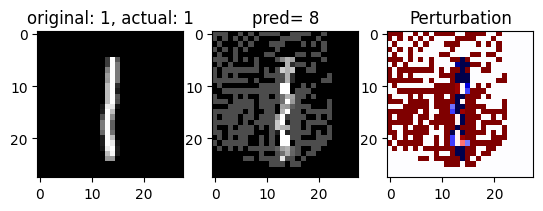

3
0.3 pred_adv:  3 P(actual): 0.4630133807659149


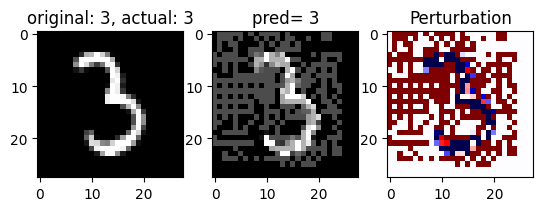

8
0.3 pred_adv:  8 P(actual): 3.602593642426655e-05


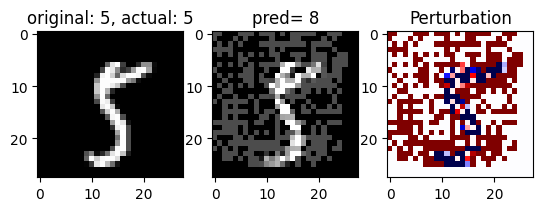

In [ ]:
index_list_test = []
#Find an image that is correctly identified
for i in range(3):
    pred = -1
    actual = -2
    while pred!= actual:
        picked_index = random.randint(0, len(x_test_extra)-1)


        image = x_test_extra[picked_index:picked_index+1]

        pred, probs = predict_tens(model, image)
    
        actual = y_test[picked_index]
    
    index_list_test.append([picked_index, probs, pred, actual])
for i in range(3):
    picked_index, probs, pred, actual = index_list_test[i]
    image = x_test_extra[picked_index:picked_index+1]
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    eps = 0.3
    x_adv, pred_adv, probs_adv = attack(actual, model, image, eps)
    print(pred_adv)
    print(eps, "pred_adv: ", pred_adv, "P(actual):", float(probs_adv[actual]))
    #Plot for the chosen epsilon
    plt.figure()

    plt.subplot(1,3,1)
    plt.imshow(image[0, ..., 0], cmap="gray")
    plt.title(f"original: {pred}, actual: {actual}")

    plt.subplot(1,3,2)
    plt.imshow(x_adv[0, ..., 0], cmap="gray")
    plt.title(f"pred= {pred_adv}")

    plt.subplot(1,3,3)
    plt.imshow((x_adv - image)[0, ..., 0], cmap = "seismic")
    plt.title("Perturbation")
    plt.show()


Now we pick an image and does each attack on it to be able to compare the results.

In [42]:

#Find image

for _ in range(10000):
    index = random.randint(0, len(x_test_extra)-1)
    pred, probs = predict(model, x_test_extra[index:index+1])
    if pred == y_test[index]:
        target_indx = index
        target_actual = y_test[index]
        target_probabilities = probs
        target_image = x_test_extra[target_indx: target_indx+1]
        break

for _ in range(100000):
    index = random.randint(0, len(x_test_extra)-1)
    pred, probs = predict(model, x_test_extra[index:index+1])
    if pred != target_actual and pred == y_test[index]:
        ci = index
        ci_predicted = pred
        i_probabilities = probs
        ci_image = x_test_extra[index]
        ci_actual = y_test[ci]
        break

number_of_pixels_edited = 50

ci_image = x_test_extra[index:index+1]
target = x_test_extra[target_indx:target_indx+1]
target_label = y_test[target_indx]


In [45]:
#Modify the image using FGSM
epsilon = 0.3
FGSM_image, FGSM_predict, _ = attack(target_label, model, target, epsilon)
print("FGSM image found")

FGSM image found


In [43]:
#Modify the image using the boundary attack
boundary_image, prediction, _, _, _, _ = boundary_attack(ci_image, target_image, model, ci_predicted, number_of_pixels_edited)
print("boundary image found")

best dist 4.398694364322969
boundary image found


In [44]:
#Modify image using greedy random search
greedy_image, pred_greedy, prob_predicted = greedy_random_search(model, target, target_label)
print("Greedy iamge found")

true label is 7 and prediction is 8, took 17 steps
Greedy iamge found


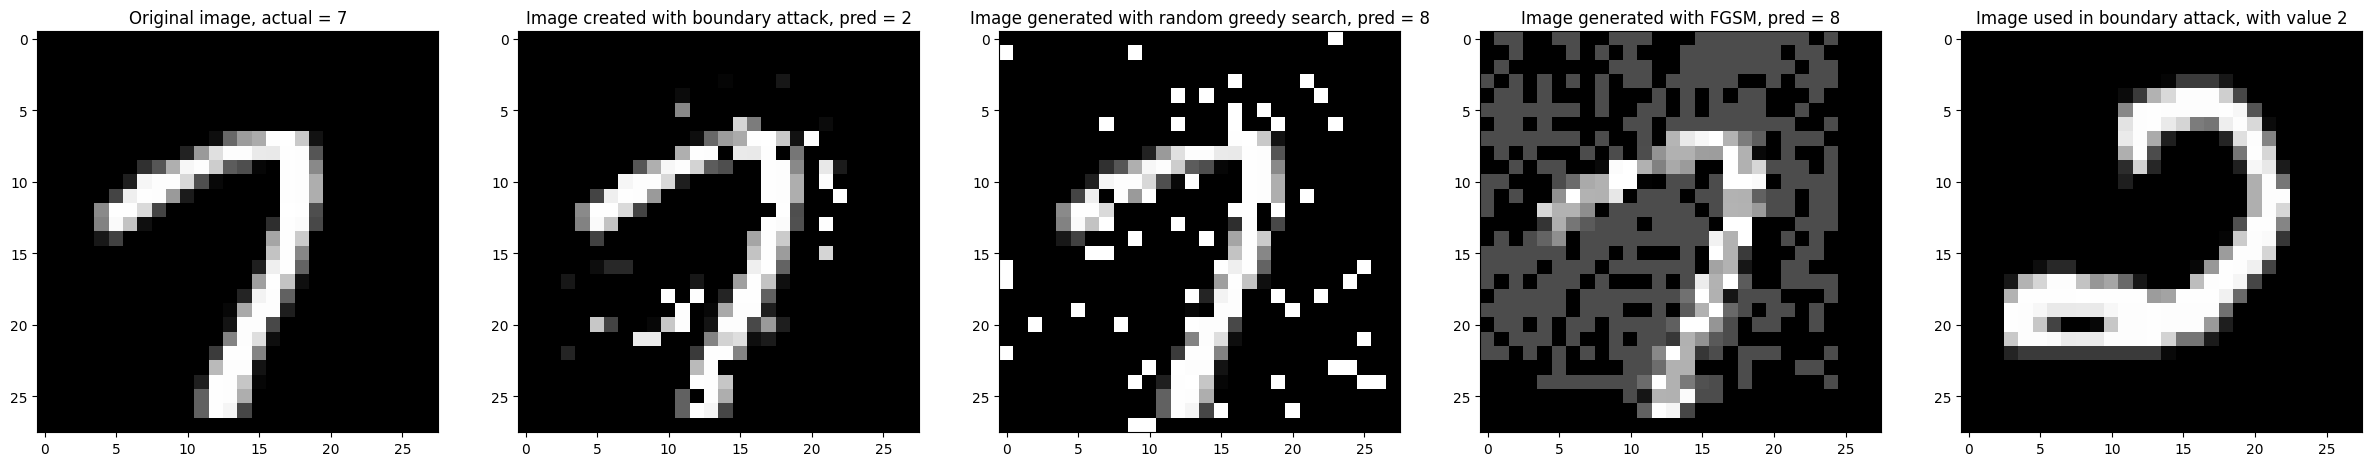

In [46]:
#Plot the images
plt.figure(figsize=(30,30))
plt.subplot(1,5,1)
plt.imshow(target[0,..., 0], cmap = "gray")
plt.title("Original image, actual = " + str(target_label))

plt.subplot(1,5,2)
plt.imshow(boundary_image[0,..., 0], cmap = "gray")
plt.title("Image created with boundary attack, pred = " + str(prediction))

plt.subplot(1,5,3)
plt.imshow(greedy_image[0,..., 0], cmap= "gray")
plt.title("Image generated with random greedy search, pred = " + str(pred_greedy))

plt.subplot(1,5,4)
plt.imshow(FGSM_image[0,..., 0], cmap="gray")
plt.title("Image generated with FGSM, pred = " + str(FGSM_predict))

plt.subplot(1,5,5)
plt.imshow(x_test_extra[ci,:,:, 0], cmap="gray")
plt.title("Image used in boundary attack, with value " + str(ci_actual))

plt.show()


Despite a high initial accuracy it was possible to easily create different types of adversial attacks to the CNN classifier. 
Three different types of adversial attacks were tried, two black box (boundary attack and greedy random search) and one white box attack (FGSM) were tried. As can be seen above, all three of them look very similar to the original image to a human being, but were misclassified by the CNN classifier. 
The different types of adversial attacks ahve diferent strengths and weaknesses. Greedy ranom search produces the most visible noisy image and is also very slow, taking significant more time than the other models. The boundary attack is quicker and produces images that to a human looks more like its true label. Both these are however black box attack, which means we do not know what the inside of the CNN classifier looks like when creating them. They are instead made by sending queries to the classifier and seeing what it returns. Boundary attacks require more queries, which might be a weakness if there classifier, for example, has a limit in the number of queries and individual can make. 
FSGM also retains a shape that very much looks like its true label, with mostly many small perturbations. Although these perturbations are very visible here (since the dataset contains mostly white digits on a black background), it is likely less visible for real-world images. This model attack does however require access to the model, whcih means that it cam not be used in most cases, since we usually dont have accesss to the model. 